In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
def convert_color(image):
    """Convert the input image to RGB."""
    return cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

In [ ]:
capture = cv2.VideoCapture(r'D:\Work\TECH\Route\C10\OT_app\vtest.avi')

In [ ]:
capture.get(cv2.CAP_PROP_FRAME_COUNT)

795.0

In [ ]:
random_frames = capture.get(cv2.CAP_PROP_FRAME_COUNT) * np.random.uniform(size=30)

In [ ]:
random_frames

array([436.07525898, 496.66854504, 511.21686869, 429.19877193,
       436.52688928,  59.49915124, 756.36154053, 312.77400772,
       197.33534564,  40.42920221, 744.22884564, 572.80592199,
       410.29113203, 532.01901436, 703.04115093, 505.42690281,
       227.80530822, 220.06054748, 227.84399288, 462.53595218,
       350.11827218, 345.36715562, 655.37928105, 374.27786657,
       226.84185697, 687.16426475, 189.47244988, 228.62597929,
       589.68521604, 392.9607334 ])

In [ ]:
frames = []
for frame_id in random_frames:
    capture.set(cv2.CAP_PROP_POS_FRAMES, frame_id)
    ret , frame = capture.read()
    frames.append(frame)
capture.release()

In [ ]:
len(frames)

30

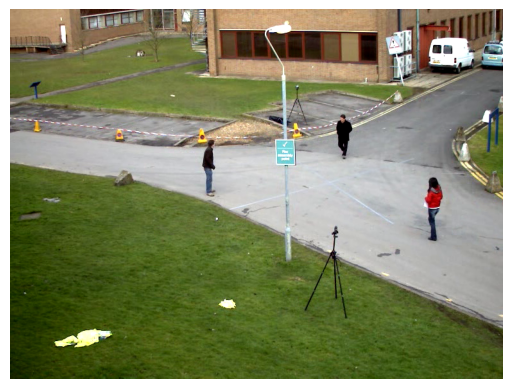

In [ ]:
plt.imshow(convert_color(frames[0]))
plt.axis('off')
plt.show()

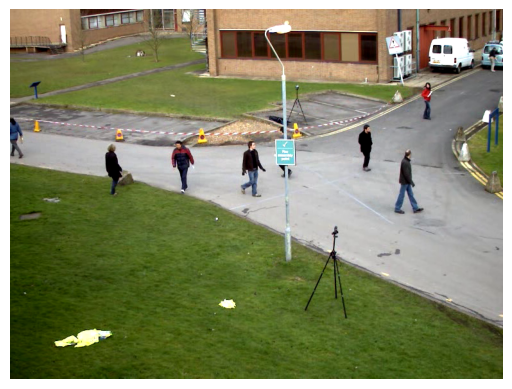

In [ ]:
plt.imshow(convert_color(frames[10]))
plt.axis('off')
plt.show()

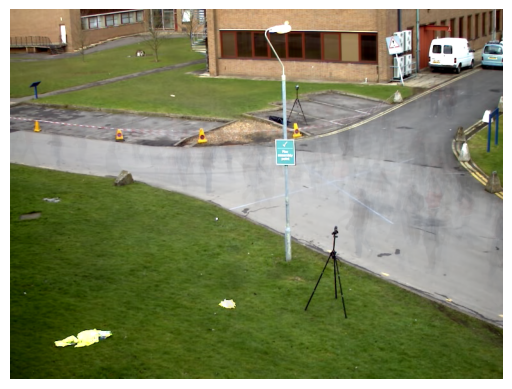

In [ ]:
avg_frame = np.average(frames,axis=0).astype(np.uint8)
plt.imshow(convert_color(avg_frame))
plt.axis('off')
plt.show()

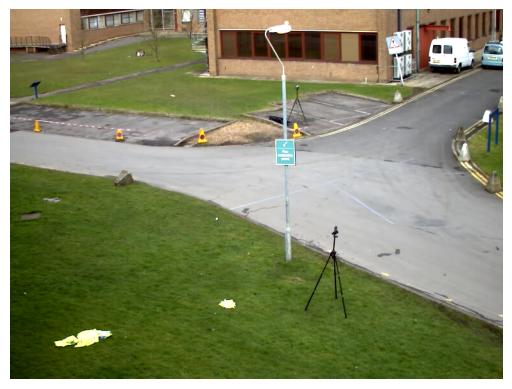

In [ ]:
avg_frame = np.median(frames,axis=0).astype(np.uint8)
plt.imshow(convert_color(avg_frame))
plt.axis('off')
plt.show()

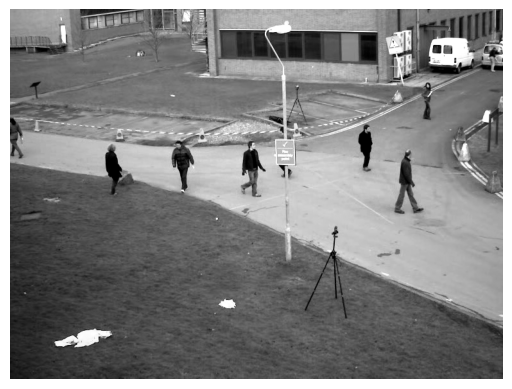

In [ ]:
framex= frames[10]
gray_frame = cv2.cvtColor(framex, cv2.COLOR_BGR2GRAY)
plt.imshow(gray_frame, cmap='gray')
plt.axis('off')
plt.show()

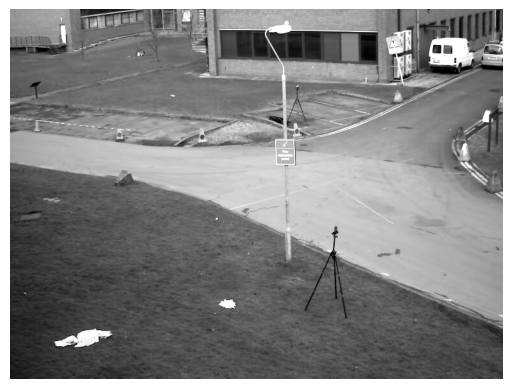

In [ ]:
background = np.median(frames,axis=0).astype(np.uint8)
gray_background = cv2.cvtColor(background, cv2.COLOR_BGR2GRAY)
plt.imshow(gray_background, cmap='gray')
plt.axis('off')
plt.show()

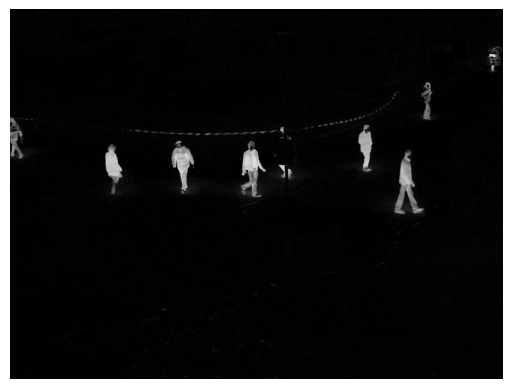

In [ ]:
background_removed = cv2.absdiff(gray_frame, gray_background)
plt.imshow(background_removed, cmap='gray')
plt.axis('off')
plt.show()

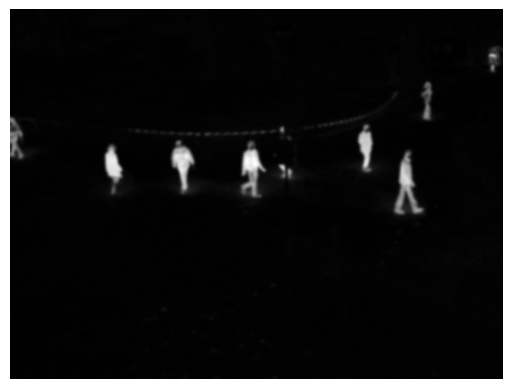

In [ ]:
background_removed_blured = cv2.GaussianBlur(background_removed, (11, 11), 0)
plt.imshow(background_removed_blured, cmap='gray')
plt.axis('off')
plt.show()

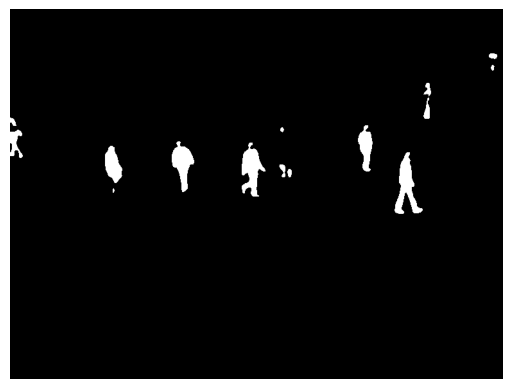

In [ ]:
_,frame_tr = cv2.threshold(background_removed_blured, 0, 255, cv2.THRESH_BINARY+cv2.THRESH_OTSU)
plt.imshow(frame_tr, cmap='gray')
plt.axis('off')
plt.show()

In [ ]:
(contours, _) = cv2.findContours(frame_tr, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

In [ ]:
len(contours)

15

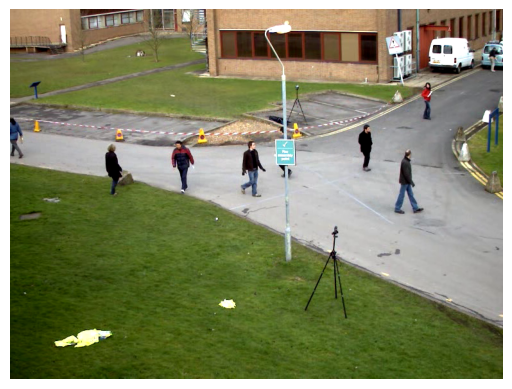

In [ ]:
plt.imshow(convert_color(framex))
plt.axis('off')
plt.show()

In [ ]:
for contour in contours:

    x,y,w,h = cv2.boundingRect(contour)
    cv2.rectangle(framex, (x,y), (x+w, y+h), (0,255,0), 2)

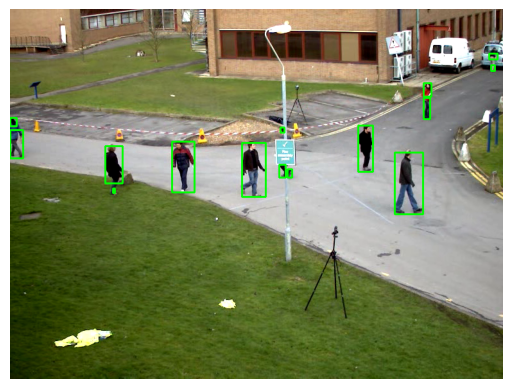

In [ ]:
plt.imshow(convert_color(framex))
plt.axis('off')
plt.show()

In [ ]:
background_subtractor= cv2.createBackgroundSubtractorMOG2()
capture = cv2.VideoCapture(r'D:\Work\TECH\Route\C10\OT_app\vtest.avi')

while capture.isOpened():
    ret, frame = capture.read()
    if not ret:
        break
    fg_mask = background_subtractor.apply(frame)
    (contours, _) = cv2.findContours(fg_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    for contour in contours:
        if cv2.contourArea(contour) > 500:
            x,y,w,h = cv2.boundingRect(contour)
            cv2.rectangle(frame, (x,y), (x+w, y+h), (0,255,0), 2)

    cv2.imshow('Frame', frame)
    cv2.imshow('FG Mask', fg_mask)

    if cv2.waitKey(30) & 0xFF == ord('q'):
        break

capture.release()
cv2.destroyAllWindows()